In [1]:
import os

# ============================================================
# ENVIRONMENT SETUP — comment out the block you are NOT using
# ============================================================

# ── Google Colab Method ──────────────────────────────────
# Mounts Drive and changes to your project folder so all
# outputs (plots, pkl) save there automatically.
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/ML-Assignment/attemp2'
# os.chdir(DRIVE_PATH)
# print(f"✓ Working directory: {DRIVE_PATH}")

# ── Local Jupyter Method ──────────────────────────────────
# Comment out this Method above and uncomment the two lines below.
# Make sure cardio_train.csv is in the same folder as this notebook.
LOCAL_PATH = os.path.dirname(os.path.abspath("__file__"))
os.chdir(LOCAL_PATH)

# Create output directories
os.makedirs("plots",  exist_ok=True)
os.makedirs("report", exist_ok=True)
print("✓ Output folders ready.")


✓ Output folders ready.


In [2]:
# ============================================================
# DATASET LOADING — comment out the block you are NOT using
# ============================================================

# ── Google Colab Method — upload file via dialog ─────────
# from google.colab import files
# print("Click Choose Files and select cardio_train.csv")
# uploaded = files.upload()
# DATASET_PATH = list(uploaded.keys())[0]
# print(f"✓ Uploaded: {DATASET_PATH}")

# ── Local Jupyter Method ──────────────────────────────────
# Comment out this method above and uncomment the line below.
DATASET_PATH = "cardio_train.csv"  # must be in the same folder as this notebook
print(f"✓ Dataset path: {DATASET_PATH}")


✓ Dataset path: cardio_train.csv


# Cardiovascular Disease Prediction
## Notebook 01: Exploratory Data Analysis & Data Preprocessing
---
**Author:** MS26912448 (Member 1)
**Dataset:** Cardiovascular Disease Dataset — Kaggle

### Objectives
This notebook covers:
1. Loading and inspecting the raw dataset
2. Exploratory Data Analysis (EDA) with visualisations
3. Data Preprocessing pipeline
4. Saving clean, scaled data for model training

In [3]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Create output directories
os.makedirs('plots', exist_ok=True)

print("✓ All libraries imported successfully.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : ", end='')
import sklearn; print(sklearn.__version__)

✓ All libraries imported successfully.
  pandas  : 3.0.2
  numpy   : 2.4.4
  sklearn : 1.8.0


## 1. Load Dataset

The dataset is stored as a semicolon-delimited CSV. We load it using `pd.read_csv` with `sep=';'`.

In [4]:
# Load the cardiovascular disease dataset
# NOTE: The dataset uses semicolon (;) as the delimiter
df = pd.read_csv(DATASET_PATH, sep=';')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded successfully!
Shape: 70,000 rows × 13 columns


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


## 2. Initial Data Inspection

In [5]:
# Display column data types and non-null counts
print("=== Dataset Information ===")
df.info()

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
# Descriptive statistics for all columns
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check data types
print("\nColumn data types:")
print(df.dtypes)

Duplicate rows: 0

Column data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


## 3. Missing Value Analysis

In [8]:
# Check for missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("=== Missing Values Summary ===")
print(missing_df[missing_df['Missing Count'] > 0] if missing.any()
      else "No missing values found in the dataset.")

=== Missing Values Summary ===
No missing values found in the dataset.


## 4. Target Variable Analysis

The target variable `cardio` is binary:
- **0**: No cardiovascular disease
- **1**: Has cardiovascular disease

We first check for class imbalance, which affects model selection and evaluation.

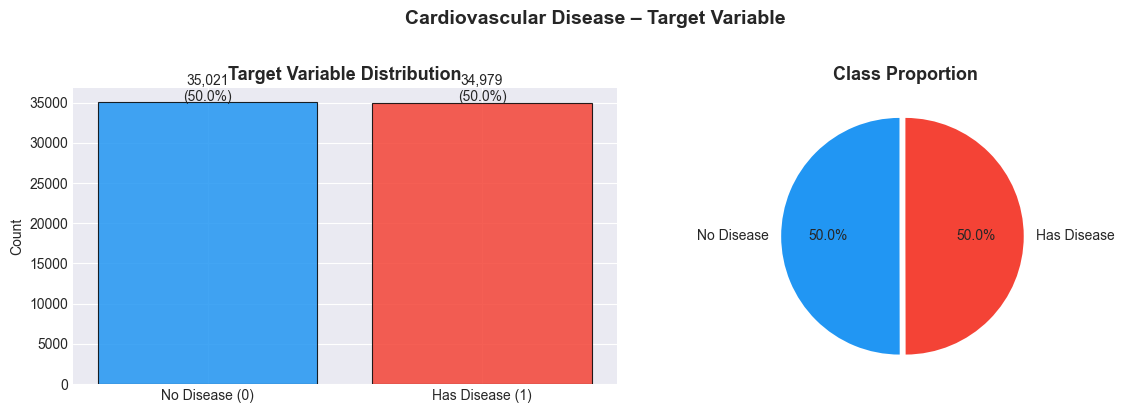

Class 0 (No Disease): 35,021 (50.0%)
Class 1 (Has Disease): 34,979 (50.0%)

Dataset is approximately balanced — no SMOTE required.


In [9]:
# Visualise target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['cardio'].value_counts().sort_index()
axes[0].bar(['No Disease (0)', 'Has Disease (1)'], counts.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Has Disease'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0.05, 0))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Cardiovascular Disease – Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class 0 (No Disease): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Has Disease): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"\nDataset is approximately balanced — no SMOTE required.")

## 5. Feature Distributions

### 5.1 Age Distribution
Age is stored in **days**. We convert to years for readability.

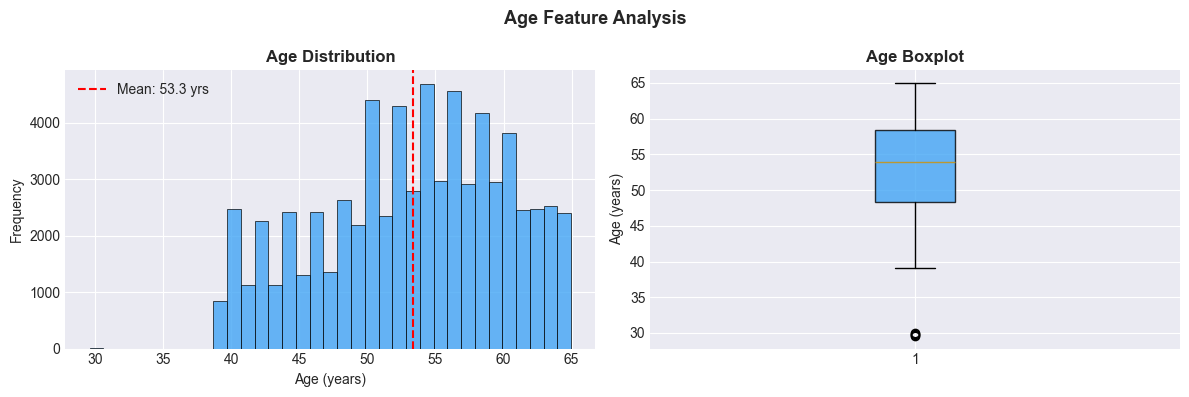

Age range : 30 – 65 years
Mean age  : 53.3 years
Std dev   : 6.8 years


In [10]:
# Age distribution (converting from days to years for visualisation)
age_years = df['age'] / 365

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(age_years, bins=35, color='#42A5F5', edgecolor='black', alpha=0.8, linewidth=0.6)
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(age_years.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {age_years.mean():.1f} yrs')
axes[0].legend()

axes[1].boxplot(age_years, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#42A5F5', alpha=0.8))
axes[1].set_title('Age Boxplot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Age (years)')

plt.suptitle('Age Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Age range : {age_years.min():.0f} – {age_years.max():.0f} years")
print(f"Mean age  : {age_years.mean():.1f} years")
print(f"Std dev   : {age_years.std():.1f} years")

### 5.2 Numerical Features (Height, Weight, Blood Pressure)

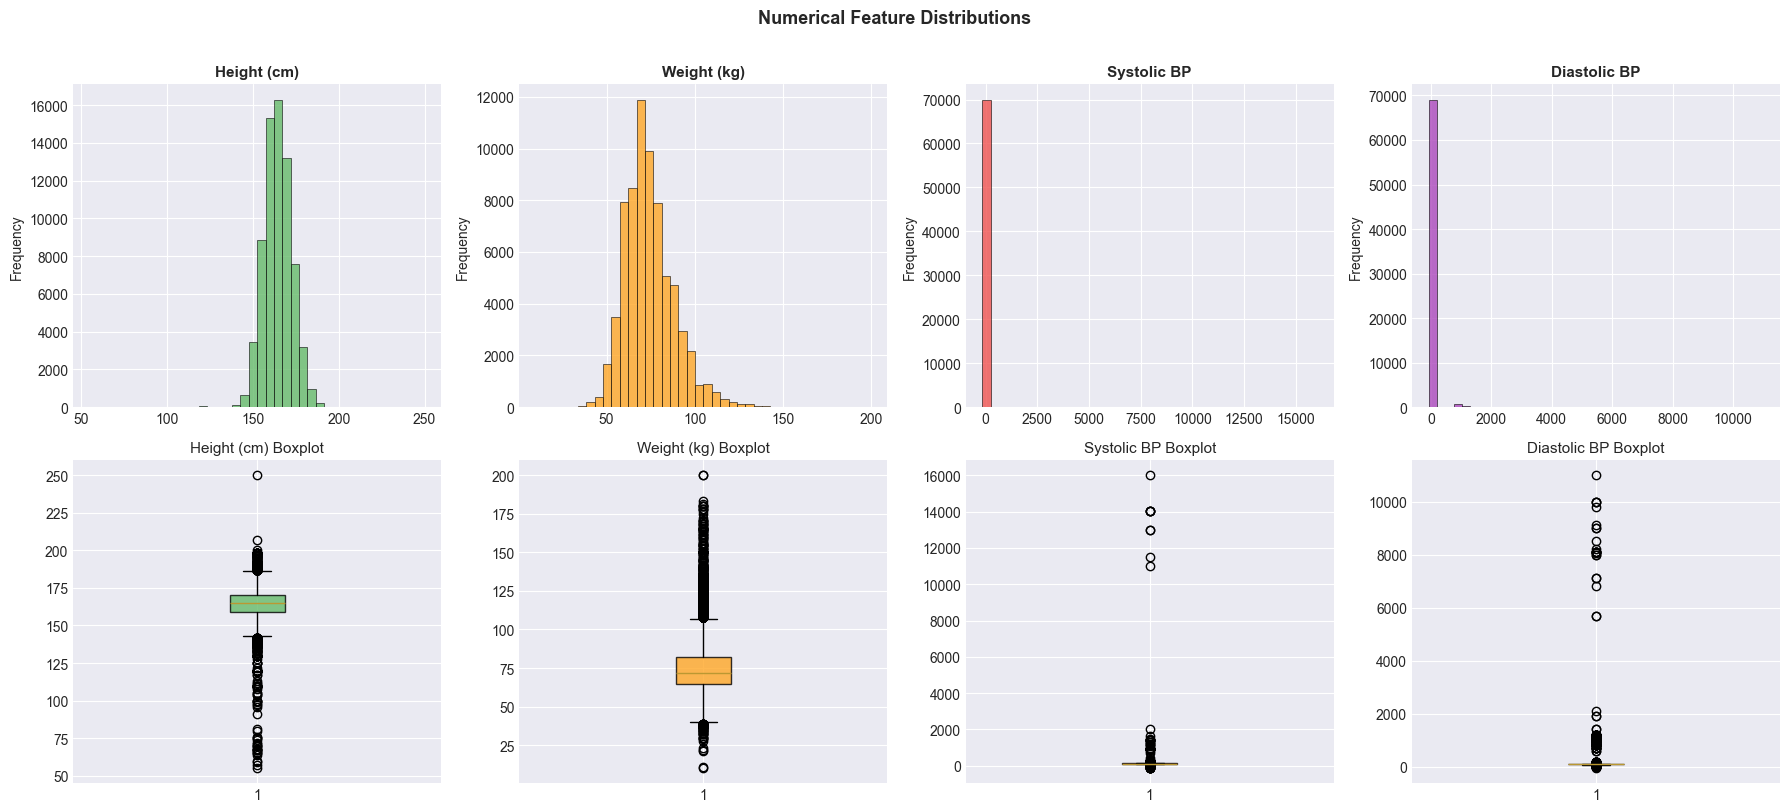

⚠ Note: Blood pressure columns contain unrealistic outliers.
  ap_hi max: 16020 | ap_lo min: -70
  These will be removed in the preprocessing step.


In [11]:
# Distribution of numerical features with boxplots
num_cols = ['height', 'weight', 'ap_hi', 'ap_lo']
colors   = ['#66BB6A', '#FFA726', '#EF5350', '#AB47BC']
labels   = ['Height (cm)', 'Weight (kg)', 'Systolic BP', 'Diastolic BP']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (col, clr, lbl) in enumerate(zip(num_cols, colors, labels)):
    # Histogram
    axes[0, i].hist(df[col], bins=40, color=clr, edgecolor='black', alpha=0.8, linewidth=0.5)
    axes[0, i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('Frequency')
    # Boxplot
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor=clr, alpha=0.8))
    axes[1, i].set_title(f'{lbl} Boxplot', fontsize=11)

plt.suptitle('Numerical Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Note significant outliers in blood pressure
print("⚠ Note: Blood pressure columns contain unrealistic outliers.")
print(f"  ap_hi max: {df['ap_hi'].max()} | ap_lo min: {df['ap_lo'].min()}")
print("  These will be removed in the preprocessing step.")

### 5.3 Categorical Features

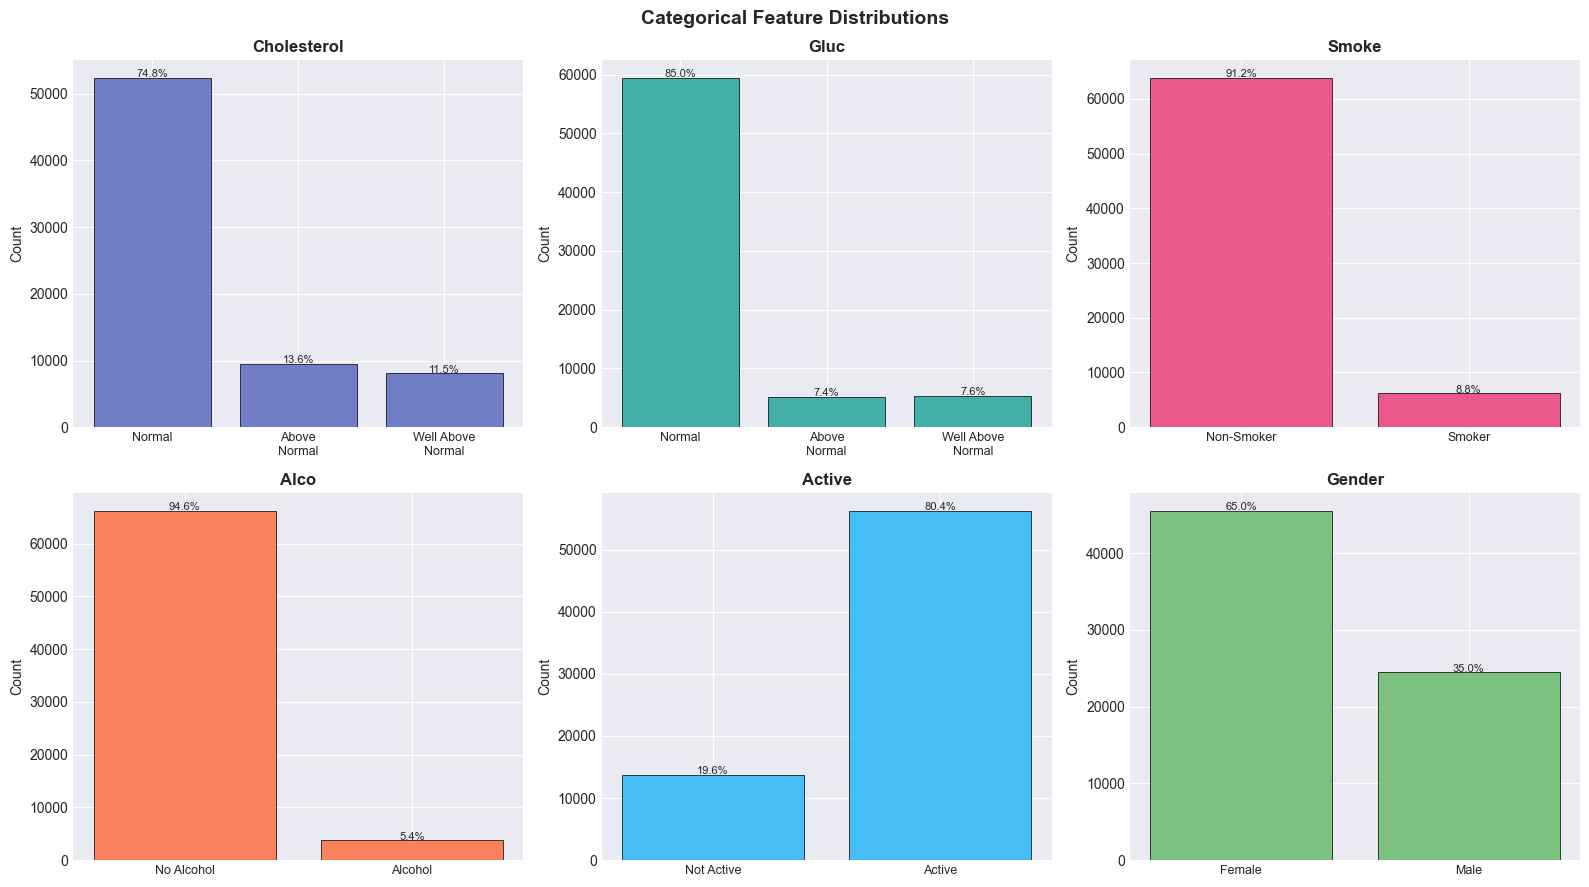

In [12]:
# Categorical feature distributions
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']
label_maps = {
    'cholesterol': {1:'Normal', 2:'Above\nNormal', 3:'Well Above\nNormal'},
    'gluc':        {1:'Normal', 2:'Above\nNormal', 3:'Well Above\nNormal'},
    'smoke':       {0:'Non-Smoker', 1:'Smoker'},
    'alco':        {0:'No Alcohol', 1:'Alcohol'},
    'active':      {0:'Not Active', 1:'Active'},
    'gender':      {1:'Female', 2:'Male'}
}
clrs = ['#5C6BC0', '#26A69A', '#EC407A', '#FF7043', '#29B6F6', '#66BB6A']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, clr) in enumerate(zip(cat_cols, clrs)):
    counts = df[col].value_counts().sort_index()
    xlabels = [label_maps[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(range(len(counts)), counts.values, color=clr, alpha=0.85,
                edgecolor='black', linewidth=0.6)
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(xlabels, fontsize=9)
    axes[i].set_title(col.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, f'{v/len(df)*100:.1f}%', ha='center', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Correlation Heatmap

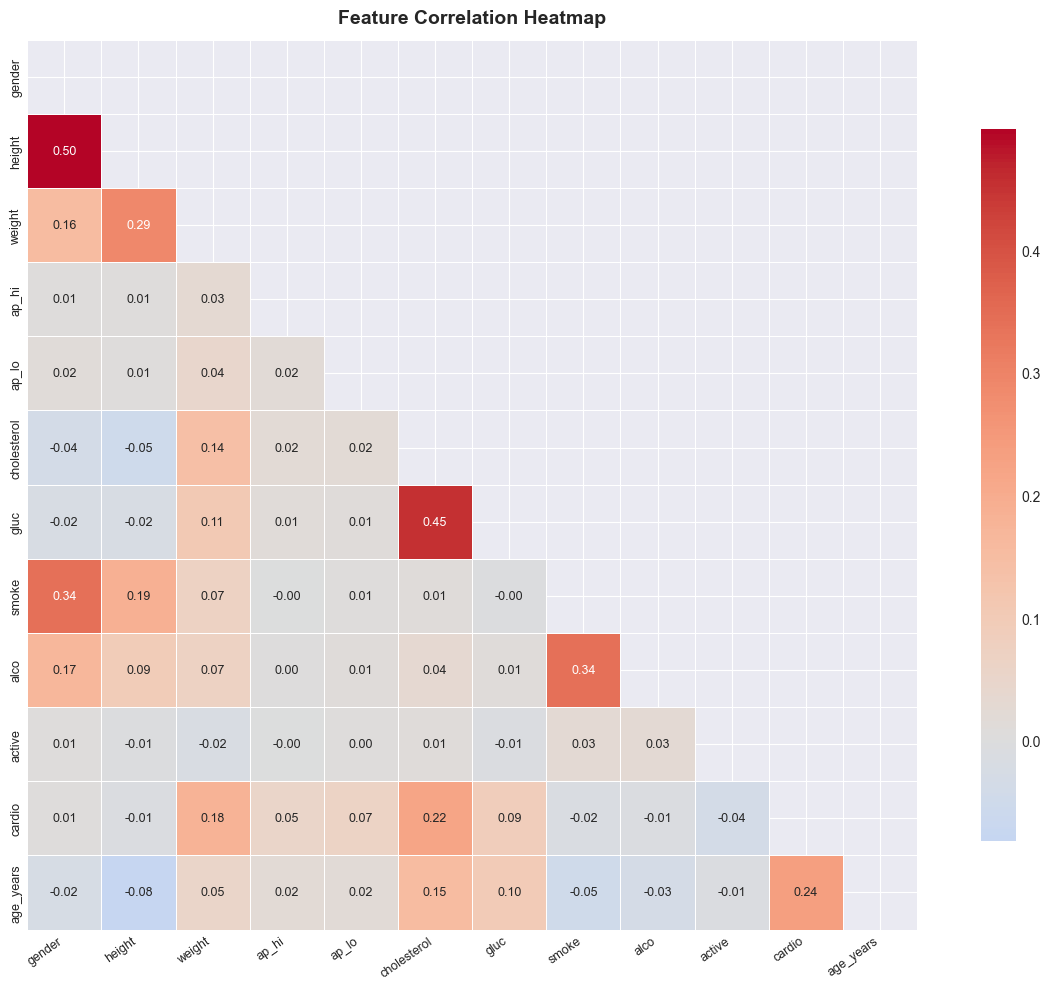

=== Top Feature Correlations with Target (cardio) ===
  age_years      : +0.238  ████
  cholesterol    : +0.221  ████
  weight         : +0.182  ███
  gluc           : +0.089  █
  ap_lo          : +0.066  █
  ap_hi          : +0.054  █
  gender         : +0.008  
  alco           : -0.007  
  height         : -0.011  
  smoke          : -0.015  
  active         : -0.036  


In [13]:
# Correlation heatmap to identify feature relationships
corr_df = df.copy()
corr_df['age_years'] = (corr_df['age'] / 365).round().astype(int)
corr_df = corr_df.drop(['id', 'age'], axis=1)

corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
target_corr = corr_matrix['cardio'].drop('cardio').sort_values(ascending=False)
print("=== Top Feature Correlations with Target (cardio) ===")
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<15}: {val:+.3f}  {bar}")

### 5.5 Feature vs Target Analysis

Comparing feature distributions across the two classes to understand discriminative features.

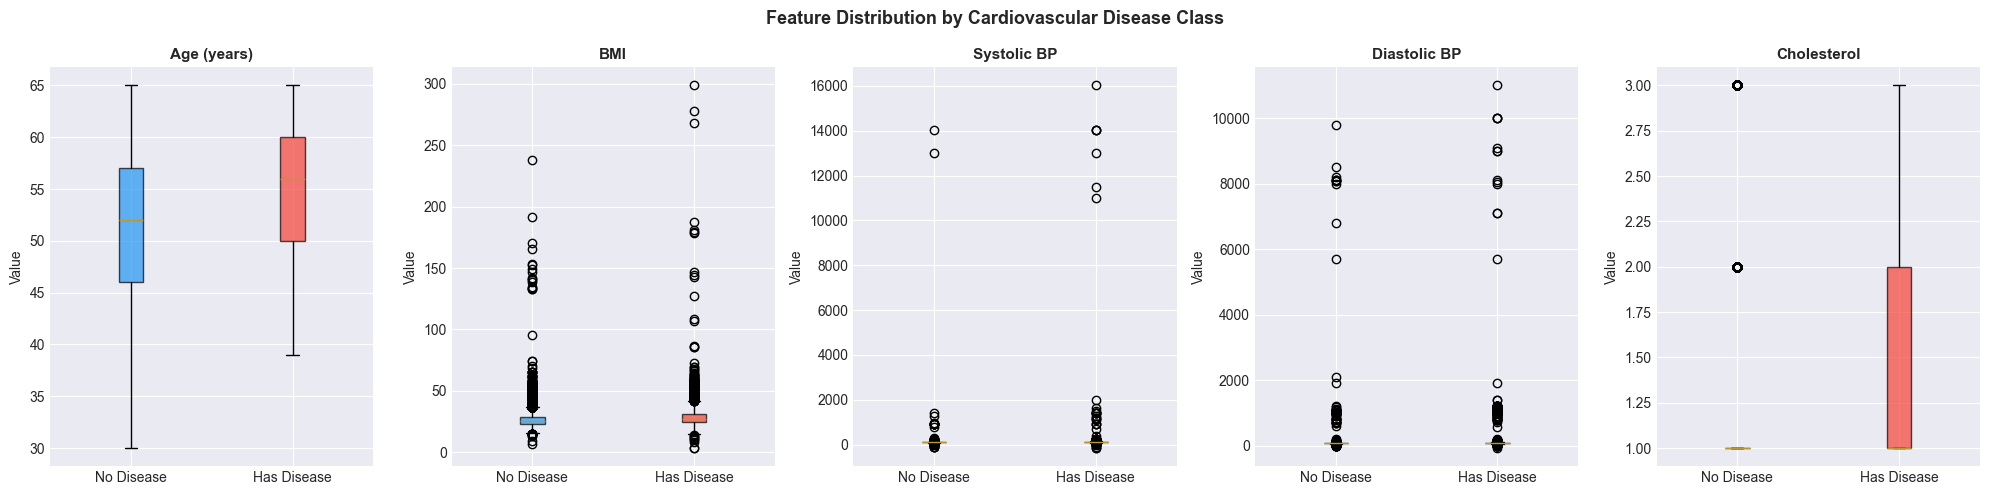

In [14]:
# Box plots comparing features by target class
key_features = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol']
temp_df = corr_df.copy()
temp_df['age_years'] = (df['age'] / 365).round()
temp_df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
feat_labels = ['Age (years)', 'BMI', 'Systolic BP', 'Diastolic BP', 'Cholesterol']
plot_feats  = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol']

box_colors = ['#2196F3', '#F44336']

for i, (feat, lbl) in enumerate(zip(plot_feats, feat_labels)):
    if feat in temp_df.columns:
        groups = [temp_df[temp_df['cardio']==0][feat].dropna(),
                  temp_df[temp_df['cardio']==1][feat].dropna()]
        bp = axes[i].boxplot(groups, labels=['No Disease', 'Has Disease'],
                             patch_artist=True)
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[i].set_title(lbl, fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution by Cardiovascular Disease Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Data Preprocessing

### 6.1 Age Conversion: Days → Years

The `age` column stores age in **days** (unusual format). We convert to years for interpretability
and drop the original `id` and raw `age` columns.

In [15]:
# Convert age from days to years; drop id and original age
df_clean = df.copy()
df_clean['age_years'] = (df_clean['age'] / 365).round().astype(int)
df_clean = df_clean.drop(['id', 'age'], axis=1)

print(f"✓ Age converted: {df_clean['age_years'].min()} – {df_clean['age_years'].max()} years")
print(f"✓ Dropped columns: ['id', 'age']")
print(f"  Remaining columns: {df_clean.columns.tolist()}")

✓ Age converted: 30 – 65 years
✓ Dropped columns: ['id', 'age']
  Remaining columns: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


### 6.2 BMI Feature Engineering

Body Mass Index (BMI) is a clinically important indicator of cardiovascular risk.
We engineer it from `height` and `weight`:

> BMI = weight(kg) / (height(m))²

We also encode BMI into categories (Underweight / Normal / Overweight / Obese).

✓ BMI feature engineered.
  BMI range : 3.5 – 298.7

BMI Category Distribution:
bmi_category
Normal         25804
Overweight     25073
Obese          18473
Underweight      650
Name: count, dtype: int64


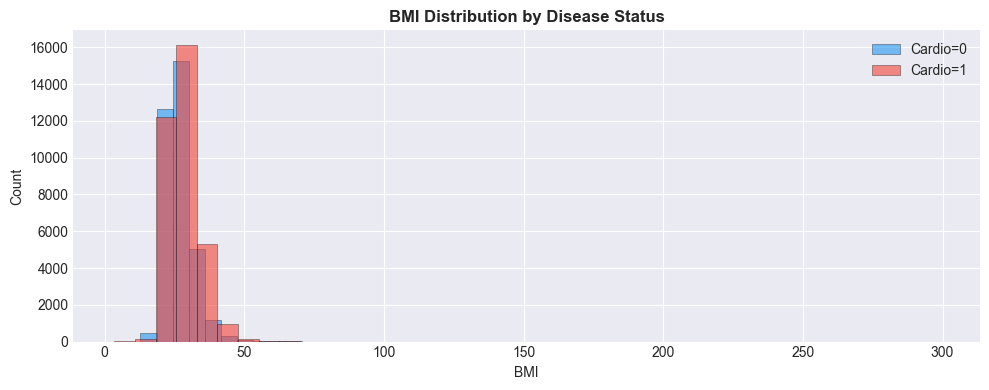

In [16]:
# Calculate BMI and BMI category
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

bmi_bins   = [0, 18.5, 25.0, 30.0, np.inf]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], bins=bmi_bins, labels=bmi_labels)

print("✓ BMI feature engineered.")
print(f"  BMI range : {df_clean['bmi'].min():.1f} – {df_clean['bmi'].max():.1f}")
print("\nBMI Category Distribution:")
print(df_clean['bmi_category'].value_counts())

# Visualise BMI by class
plt.figure(figsize=(10, 4))
for label, clr in zip([0, 1], ['#2196F3', '#F44336']):
    subset = df_clean[df_clean['cardio'] == label]['bmi']
    plt.hist(subset, bins=40, alpha=0.6, color=clr,
             label=f'Cardio={label}', edgecolor='black', linewidth=0.4)
plt.title('BMI Distribution by Disease Status', fontsize=12, fontweight='bold')
plt.xlabel('BMI'); plt.ylabel('Count'); plt.legend()
plt.tight_layout()
plt.savefig('plots/07_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Outlier Removal

#### Blood Pressure Outliers
Medical reference ranges:
- Systolic BP (`ap_hi`): realistic range **80–200 mmHg**
- Diastolic BP (`ap_lo`): realistic range **50–140 mmHg**
- Systolic must always be **≥ diastolic**

#### Height / Weight Outliers
- Height: **140–220 cm** (realistic adult range)
- Weight: **30–200 kg** (realistic adult range)

In [17]:
# Record original size
original_size = len(df_clean)
print(f"Dataset size before cleaning: {original_size:,}")

# Remove blood pressure outliers
df_clean = df_clean[(df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 200)]
df_clean = df_clean[(df_clean['ap_lo'] >= 50) & (df_clean['ap_lo'] <= 140)]
df_clean = df_clean[df_clean['ap_hi'] >= df_clean['ap_lo']]

# Remove height/weight outliers
df_clean = df_clean[(df_clean['height'] >= 140) & (df_clean['height'] <= 220)]
df_clean = df_clean[(df_clean['weight'] >= 30)  & (df_clean['weight'] <= 200)]

# Remove extreme BMI values
df_clean = df_clean[(df_clean['bmi'] >= 10) & (df_clean['bmi'] <= 60)]

cleaned_size = len(df_clean)
removed = original_size - cleaned_size

print(f"Dataset size after cleaning : {cleaned_size:,}")
print(f"Rows removed (outliers)     : {removed:,} ({removed/original_size*100:.2f}%)")
print(f"\nClass balance after cleaning:")
print(df_clean['cardio'].value_counts(normalize=True).round(4))

Dataset size before cleaning: 70,000
Dataset size after cleaning : 68,425
Rows removed (outliers)     : 1,575 (2.25%)

Class balance after cleaning:
cardio
0    0.5055
1    0.4945
Name: proportion, dtype: float64


### 6.4 Encode Categorical Variables

`bmi_category` is an ordinal variable (has a natural order), so we use ordinal encoding.

In [18]:
# Ordinal encode BMI category (natural order: 0=Underweight → 3=Obese)
bmi_map = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df_clean['bmi_category'] = df_clean['bmi_category'].map(bmi_map)

# Verify all columns are numeric
print("✓ Encoding complete. Column types:")
print(df_clean.dtypes)
print(f"\nFinal feature set: {df_clean.columns.tolist()}")

✓ Encoding complete. Column types:
gender             int64
height             int64
weight           float64
ap_hi              int64
ap_lo              int64
cholesterol        int64
gluc               int64
smoke              int64
alco               int64
active             int64
cardio             int64
age_years          int64
bmi              float64
bmi_category    category
dtype: object

Final feature set: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bmi_category']


### 6.5 Train-Test Split (80/20) and Feature Scaling

We use **stratified splitting** to preserve class balance across train and test sets.
**StandardScaler** normalises all features to zero mean and unit variance — essential for SVM.

In [19]:
# Separate features and target
X = df_clean.drop('cardio', axis=1)
y = df_clean['cardio']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✓ Train set: {X_train.shape[0]:,} samples")
print(f"✓ Test  set: {X_test.shape[0]:,} samples")

# StandardScaler normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train ONLY
X_test_scaled  = scaler.transform(X_test)         # transform test with same scaler

print("\n✓ Features scaled with StandardScaler.")
print(f"  Scaled mean ≈ 0 (train check): {X_train_scaled.mean():.6f}")
print(f"  Scaled std  ≈ 1 (train check): {X_train_scaled.std():.6f}")

Features (13): ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bmi_category']
Target distribution:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64

✓ Train set: 54,740 samples
✓ Test  set: 13,685 samples

✓ Features scaled with StandardScaler.
  Scaled mean ≈ 0 (train check): 0.000000
  Scaled std  ≈ 1 (train check): 1.000000


### 6.6 Save Preprocessed Data

In [20]:
# Save all preprocessed data to pickle for use in model notebooks
preprocessed = {
    'X_train':      X_train_scaled,
    'X_test':       X_test_scaled,
    'y_train':      y_train.values,
    'y_test':       y_test.values,
    'feature_names': feature_names,
    'scaler':       scaler
}

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(preprocessed, f, protocol=4)

print("✓ Preprocessed data saved to 'preprocessed_data.pkl'")
print("\n=== Final Preprocessing Summary ===")
print(f"  Total samples    : {len(X_train_scaled) + len(X_test_scaled):,}")
print(f"  Training samples : {len(X_train_scaled):,}")
print(f"  Test samples     : {len(X_test_scaled):,}")
print(f"  Features         : {len(feature_names)}")
print(f"  Features list    : {feature_names}")

✓ Preprocessed data saved to 'preprocessed_data.pkl'

=== Final Preprocessing Summary ===
  Total samples    : 68,425
  Training samples : 54,740
  Test samples     : 13,685
  Features         : 13
  Features list    : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bmi_category']


---
## 7. Preprocessing Summary

| Step                     | Action Taken                                              |
|--------------------------|-----------------------------------------------------------|
| Age Conversion           | Converted from days → years, dropped original `age`       |
| BMI Engineering          | Calculated BMI from height/weight; ordinal-encoded category|
| ID Column                | Dropped `id` (non-predictive)                             |
| Blood Pressure Outliers  | Removed records outside medical reference ranges          |
| Height/Weight Outliers   | Removed biologically impossible values                    |
| Encoding                 | Ordinal encoding for BMI category                         |
| Train-Test Split         | 80/20 stratified split (random_state=42)                  |
| Scaling                  | StandardScaler fitted on train set only                   |

**Ready for model training.** Proceed to Notebook 02 (Random Forest) and 03 (SVM).